In [1]:
import numpy as np
from matplotlib import pyplot as plt
import xarray as xr

import zipfile as zp          # used for unzipping ppi files
from pathlib import Path      # used to play with pathnames to save 
from datetime import datetime # used to manipulate time :)


import wradlib as wr          # used for having fun with radar data

from PIL import Image         # used for creating gif loops
import os                     # used for retrieving file names

import h5py                   # used for reading .h5 files (Radar Level 1 data)
import h5netcdf               # used for converting .h5 files to NetCDF

In [2]:
# IMPORTED FROM EXAMPLE RADAR PYTHON SCRIPT

# import os #used for system commands
# import tempfile #used to create temporary folders to store data
# import zipfile #used to extract tar files
# import urllib #used to download data via http
# from datetime import datetime #used to manipulate time :)
# from glob import glob #used for manipulating pathnames

# import numpy as np 
# from matplotlib import pyplot as plt

# import pyart

# from matplotlib import animation
# from IPython.display import HTML
# import cartopy.crs as ccrs # A toolkit for map projections

In [3]:
# FUNCTION
#pcolormesh but takes 1D X and Y coordinates for centres of the pixels

def pcolormeshC(x_centers, y_centers, z, ax=None,
                            shading='auto', **pcolor_kwargs):
    """
    Create a pcolormesh from a 2D array and 1D coordinate-center arrays.

    Parameters
    ----------
    x_centers : 1D array
        X coordinates of cell centers (length = number of columns in z)
    y_centers : 1D array
        Y coordinates of cell centers (length = number of rows in z)
    z : 2D array
        Data array with shape (len(y_centers), len(x_centers))
    ax : matplotlib.axes.Axes, optional
        Existing axis to draw on
    shading : str
        Passed to pcolormesh (default: 'auto')
    **pcolor_kwargs
        Extra kwargs passed to pcolormesh

    Returns
    -------
    pcm : QuadMesh
        The pcolormesh object
    """

    x_centers = np.asarray(x_centers)
    y_centers = np.asarray(y_centers)
    z = np.asarray(z)

    if z.shape != (len(y_centers), len(x_centers)):
        raise ValueError(
            f"z shape {z.shape} does not match "
            f"(len(y_centers), len(x_centers)) = "
            f"({len(y_centers)}, {len(x_centers)})"
        )

    # Convert centers -> edges
    def centers_to_edges(c):
        dc = np.diff(c)

        edges = np.empty(len(c) + 1)

        # Interior edges
        edges[1:-1] = c[:-1] + dc / 2

        # Extrapolate outer edges
        edges[0] = c[0] - dc[0] / 2
        edges[-1] = c[-1] + dc[-1] / 2

        return edges

    x_edges = centers_to_edges(x_centers)
    y_edges = centers_to_edges(y_centers)

    if ax is None:
        fig, ax = plt.subplots()

    pcm = ax.pcolormesh(
        x_edges,
        y_edges,
        z,
        shading=shading,
        **pcolor_kwargs
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")

    return pcm

In [4]:
# FUNCTION
# creates a histogram taking a 2D array and ignores nans AND ABSOLUTE VALUES ABOVE 10

def hist2d(arr, bins=50, density=False, ax=None, **hist_kwargs):
    """
    Create a histogram of all non-NaN values in a 2D NumPy array.

    Parameters
    ----------
    arr : np.ndarray
        Input 2D array.
    bins : int or sequence, optional
        Number of histogram bins or bin edges.
    density : bool, optional
        If True, normalize the histogram.
    ax : matplotlib.axes.Axes, optional
        Existing matplotlib axis to plot on.
    **hist_kwargs
        Extra keyword arguments passed to plt.hist().

    Returns
    -------
    hist : tuple
        Output from matplotlib hist():
        (counts, bin_edges, patches)
    """

    # Flatten array and remove NaNs 
    values = arr[~np.isnan(arr)]

    # Create axis if needed
    if ax is None:
        fig, ax = plt.subplots()

    # Plot histogram
    hist = ax.hist(values, bins=bins, density=density, **hist_kwargs)

    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency" if not density else "Density")
    ax.set_title("Histogram of Non-NaN Values")

    return hist

In [5]:
# FUNCTION
# creates a histogram taking a 2D array and ignores nans AND ABSOLUTE VALUES ABOVE 10

def hist2dsmall(arr, bins=50, density=False, ax=None, **hist_kwargs):
    """
    Create a histogram of all non-NaN values in a 2D NumPy array.

    Parameters
    ----------
    arr : np.ndarray
        Input 2D array.
    bins : int or sequence, optional
        Number of histogram bins or bin edges.
    density : bool, optional
        If True, normalize the histogram.
    ax : matplotlib.axes.Axes, optional
        Existing matplotlib axis to plot on.
    **hist_kwargs
        Extra keyword arguments passed to plt.hist().

    Returns
    -------
    hist : tuple
        Output from matplotlib hist():
        (counts, bin_edges, patches)
    """

    # Flatten array and remove NaNs OR ABSOLUTE VALUES ABOVE 10
    values = arr[~np.isnan(arr) & (np.abs(arr) <= 10)]

    # Create axis if needed
    if ax is None:
        fig, ax = plt.subplots()

    # Plot histogram
    hist = ax.hist(values, bins=bins, density=density, **hist_kwargs)

    ax.set_xlabel("Value")
    ax.set_ylabel("Frequency" if not density else "Density")
    ax.set_title("Histogram of Non-NaN Values")

    return hist

Unzipped Folder Already Exists


/jobfs/169509607.gadi-pbs/ipykernel_316854/1041859280.py:52: FutureWarning: In a future version, xarray will not decode the variable 'prt' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  RadarDataStruct = xr.open_dataset(RadarFolder + RadarFile, engine='netcdf4')


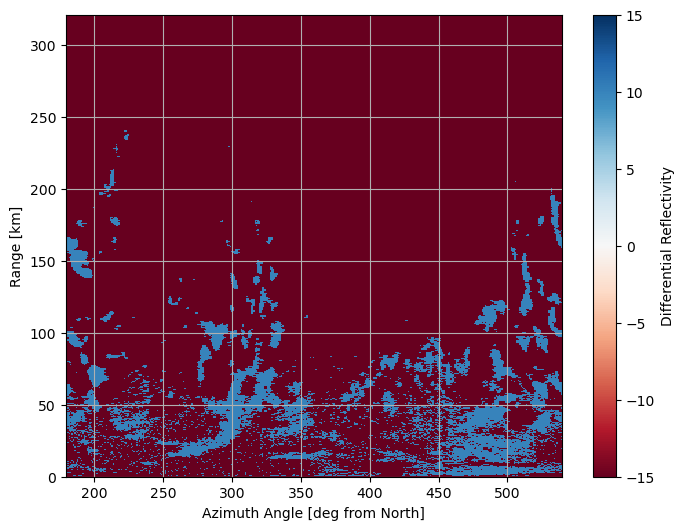

(array([5699692.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,       0.,       0.,       0.,       0.,       0.,
              0.,  304748.]),
 array([-1.50000000e+01, -1.44999969e+01, -1.39999939e+01, -1.34999908e+01,
        -1.29999878e+01, -1.24999847e+01, -1.19999817e+01, -1.14999786e+01,
        -1.09999756e+01, -1.04999725e+01, -9.99996948e+00, -9.49996643e+00,
        -8.99996338e+00, -8.49996033e+00, -7.99995727e+00, -7.49995422e+00,
        -6.99995117e+00, -6.49994812e+00, -5.99994507e+00, -5.49994201e+00,
        -4.99993896e+00, -4.49993591e+00, -3.9

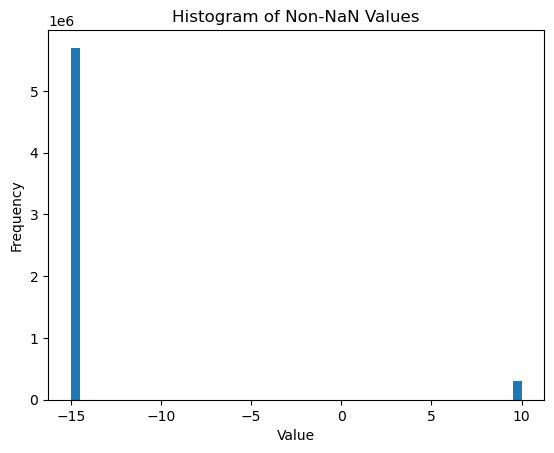

In [44]:
# NOT A LOOP
# ALL IN ONE BLOCK

# the reference number for the radar location (ie 20 is Mackay)
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)
GridOrPPI = 'ppi'

# the day in consideration (YYYYMMDD) and time (hhmmss)
# ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 3
RadarDay   = 9

RadarFileDate  = str(RadarYear).zfill(4) + str(RadarMonth).zfill(2) + str(RadarDay).zfill(2)
RadarFileTime =   '000000'



# THIS BLOCK TAKES A ZIPPED FOLDER FROM /G/DATA/ AND UNZIPS IT TO A FOLDER "nzippedRadarFiles" IN SCRATCH

# PATH NAMES
# ZippedFolder = '/g/data/rq0/level_1b/22/ppi/2024/'
ZippedFolder = '/g/data/rq0/level_1b/' + RadarIDno + '/' + GridOrPPI + '/' + str(RadarYear) + '/'
ZippedFile   =  RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '.zip'

# place where the zipped file lives
ZippedPath = ZippedFolder + ZippedFile
# place to extract the files to
ExtractToDirectory = Path('/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/')

# Create the extraction folder (only if you haven't already)
if not Path(ExtractToDirectory).exists():
    ExtractToDirectory.mkdir(parents=True, exist_ok=True)

    # actually do the unzipping
    with zp.ZipFile(ZippedPath, 'r') as ZipReference:
        ZipReference.extractall(ExtractToDirectory)

    print('Done')
else:
    print('Unzipped Folder Already Exists')



# READ IN THE DATA TO AN XARRAY DATAFRAME

# the path of where the UNZIPPED radar data now live
RadarFolder = '/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/'
RadarFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + GridOrPPI + '.nc'

# open the radar data into an xarray data structure
RadarDataStruct = xr.open_dataset(RadarFolder + RadarFile, engine='netcdf4')


# Variables to plot in the 2D pcolormesh
Phis   = RadarDataStruct.elevation[::360] # retrieve set of all 13 elevation angles
Thetas = np.round(RadarDataStruct.azimuth[0:360])   # retrieve set of all 360 azimuth angles
Ranges = RadarDataStruct.range

# create a 13 elevation by 360 azimuth by 1283 range 3D array for ZDR
ZDR3D = np.reshape(np.array(RadarDataStruct.corrected_differential_reflectivity),[13,360,1283])

fig, ax = plt.subplots(figsize=(8,6))
RangeViewer = pcolormeshC(Thetas+180, Ranges*0.001, np.transpose(ZDR3D[1]), ax=ax, cmap='RdBu', vmin=-15, vmax=15)

ax.set_xlabel('Azimuth Angle [deg from North]')
ax.set_ylabel('Range [km]')
plt.colorbar(RangeViewer, ax=ax, label = 'Differential Reflectivity')
plt.grid()

plt.show()


hist2d(np.array(RadarDataStruct.corrected_differential_reflectivity))

In [6]:
# THIS BLOCK IS WHERE THE USER PUTS INFO ABOUT THE RADAR

# the reference number for the radar location (ie 20 is Mackay)
RadarIDno = '106'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)
GridOrPPI = 'ppi'

# the day in consideration (YYYYMMDD) and time (hhmmss)
# ALL IN UTC !!!
RadarYear  = 2024
RadarMonth = 11
RadarDay   = 9

RadarFileDate  = str(RadarYear).zfill(4) + str(RadarMonth).zfill(2) + str(RadarDay).zfill(2)
RadarFileTime =   '000000'

In [7]:
# THIS BLOCK TAKES A ZIPPED FOLDER FROM /G/DATA/ AND UNZIPS IT TO A FOLDER "nzippedRadarFiles" IN SCRATCH

# PATH NAMES
# ZippedFolder = '/g/data/rq0/level_1b/22/ppi/2024/'
ZippedFolder = '/g/data/rq0/level_1b/' + RadarIDno + '/' + GridOrPPI + '/' + str(RadarYear) + '/'
ZippedFile   =  RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '.zip'

# place where the zipped file lives
ZippedPath = ZippedFolder + ZippedFile
# place to extract the files to
ExtractToDirectory = Path('/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/')

# Create the extraction folder (only if you haven't already)
if not Path(ExtractToDirectory).exists():
    ExtractToDirectory.mkdir(parents=True, exist_ok=True)

    # actually do the unzipping
    with zp.ZipFile(ZippedPath, 'r') as ZipReference:
        ZipReference.extractall(ExtractToDirectory)

    print('Done')
else:
    print('Unzipped Folder Already Exists')

Unzipped Folder Already Exists


In [8]:
# READ IN THE DATA TO AN XARRAY DATAFRAME

# the path of where the UNZIPPED radar data now live
RadarFolder = '/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/'
RadarFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + GridOrPPI + '.nc'

# open the radar data into an xarray data structure
RadarDataStruct = xr.open_dataset(RadarFolder + RadarFile, engine='netcdf4')

/jobfs/169956987.gadi-pbs/ipykernel_3536336/1157562372.py:8: FutureWarning: In a future version, xarray will not decode the variable 'prt' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  RadarDataStruct = xr.open_dataset(RadarFolder + RadarFile, engine='netcdf4')


In [10]:
RadarDataStruct.range

<xarray.DataArray 'range' (range: 1283)> Size: 5kB
array([1.25000e+02, 3.75000e+02, 6.25000e+02, ..., 3.20125e+05, 3.20375e+05,
       3.20625e+05], shape=(1283,), dtype=float32)
Coordinates:
  * range    (range) float32 5kB 125.0 375.0 625.0 ... 3.204e+05 3.206e+05
Attributes:
    long_name:                       range_to_measurement_volume
    units:                           meters
    axis:                            radial_range_coordinate
    spacing_is_constant:             true
    comment:                         Coordinate variable for range. Range to ...
    meters_to_center_of_first_gate:  0.0
    meters_between_gates:            250.0
    coverage_content_type:           coordinate

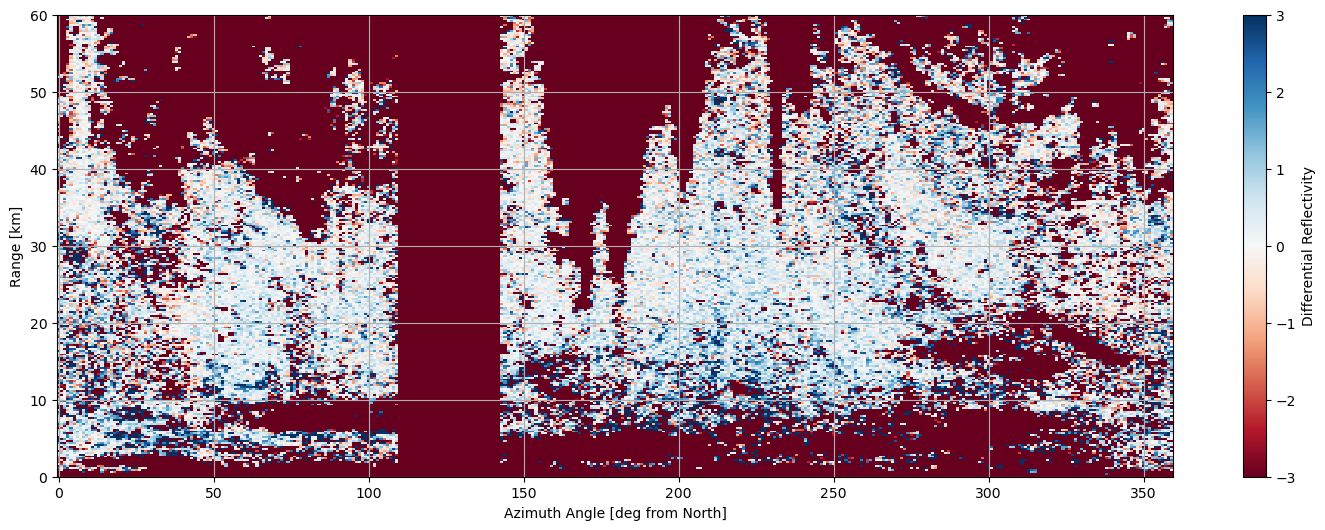

In [70]:
Phis   = RadarDataStruct.elevation[::360] # retrieve set of all 13 elevation angles
Thetas = np.round(RadarDataStruct.azimuth[0:360])   # retrieve set of all 360 azimuth angles
Ranges = RadarDataStruct.range

# create a 13 elevation by 360 azimuth by 1283 range 3D array for ZDR
ZDR3D = np.reshape(np.array(RadarDataStruct.corrected_differential_reflectivity),[13,360,1283])

fig, ax = plt.subplots(figsize=(18,6))
RangeViewer = pcolormeshC(np.arange(0,360,1), Ranges*0.001, np.transpose(ZDR3D[1]), ax=ax, cmap='RdBu', vmin=-3, vmax=3)

ax.set_xlabel('Azimuth Angle [deg from North]')
ax.set_ylabel('Range [km]')
plt.colorbar(RangeViewer, ax=ax, label = 'Differential Reflectivity')
plt.grid()

plt.ylim([0,60])

plt.show()

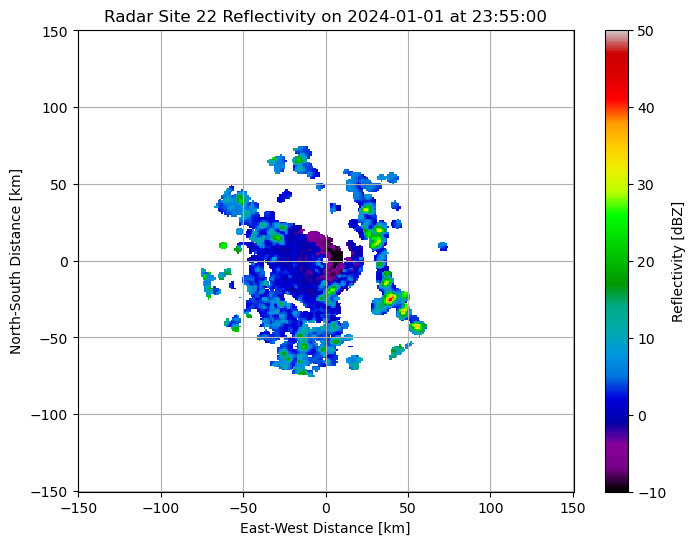

In [157]:
# Create a plot of the reflectivity for each 5-min period

fig, ax = plt.subplots(figsize=(8,6))
GridViewer = pcolormeshC(RadarDataStruct.x*0.001, RadarDataStruct.y*0.001, RadarDataStruct.corrected_reflectivity[0,2,:,:], ax=ax, cmap='nipy_spectral', vmin=-10, vmax=50)
# mutiply by 0.001 to get distances in km

ax.set_xlabel('East-West Distance [km]')
ax.set_ylabel('North-South Distance [km]')
plt.title('Radar Site ' + str(RadarIDno) + ' Reflectivity on ' + RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
          str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6])
plt.colorbar(GridViewer, ax=ax, label = 'Reflectivity [dBZ]')
plt.grid()

SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/'
SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + GridOrPPI + '500m.png'

SavePath = SaveFolder + SaveFile

if not Path(SaveFolder).exists():
    print('doing')
    Path(SaveFolder).mkdir(parents=True, exist_ok=True)

# plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)

In [12]:
# ALL IN ONE BLOCK TO LOOP

# THIS BLOCK IS WHERE THE USER PUTS INFO ABOUT THE RADAR

# the reference number for the radar location (ie 20 is Mackay)
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)
GridOrPPI = 'grid'

if (RadarIDno == 22):
    RadarName = 'Mackay'
elif (RadarIDno == 106):
    RadarName = 'Townsville'
elif (RadarIDno == 2):
    RadarName = 'Melbourne'
elif (RadarIDno == 19):
    RadarName = 'Cairns'
elif (RadarIDno == 50):
    RadarName = 'Marburg'
elif (RadarIDno == 66):
    RadarName = 'Mount Staplyton'
else:
    RadarName = str(RadarIDno)

# the day in consideration (YYYYMMDD) and time (hhmmss)
# ALL IN UTC !!!
RadarYear  = 2024
# RadarMonth = 11
# RadarDay   = 7

MonthStart = [1, 1, 9, 1, 1, 1, 1, 1, 1, 1, 1, 1] # which day of the month do you want to start reading data from?
DaysInMonth = [31, 29, 9, 30, 31, 30, 31, 31, 30, 31, 30, 31] # number of days in each month of the year

for RadarMonth in range(3,4):
    for RadarDay in range(MonthStart[RadarMonth-1],DaysInMonth[RadarMonth-1] + 1):

        RadarFileDate  = str(RadarYear).zfill(4) + str(RadarMonth).zfill(2) + str(RadarDay).zfill(2)  # UTC date of the radar data
        RadarFileDatePrint = RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] # add a string of format YYYY-MM-DD for printing

        # THIS BLOCK TAKES A ZIPPED FOLDER FROM /G/DATA/ AND UNZIPS IT TO A FOLDER "nzippedRadarFiles" IN SCRATCH
                
        # PATH NAMES
        # ZippedFolder = '/g/data/rq0/level_1b/22/ppi/2024/'
        ZippedFolder = '/g/data/rq0/level_1b/' + RadarIDno + '/' + GridOrPPI + '/' + str(RadarYear) + '/'
        ZippedFile   =  RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '.zip'
        
        # place where the zipped file lives
        ZippedPath = ZippedFolder + ZippedFile
        # place to extract the files to
        ExtractToDirectory = Path('/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/')
        
        # Create the extraction folder (only if you haven't already)
        if not Path(ExtractToDirectory).exists():
            ExtractToDirectory.mkdir(parents=True, exist_ok=True)

            with zp.ZipFile(ZippedPath, 'r') as ZipReference:
                ZipReference.extractall(ExtractToDirectory)
            print('Unzipped into Scratch')
        else:
            print('Unzipped Folder Already Exists')
    
        # actually do the unzipping
        if Path(ZippedPath).is_file():

            # loop over every 5 min period in the day
            for houri in range(0,24):
                for mini in range(0,60,5):
                    RadarFileTime = str(houri).zfill(2) + str(mini).zfill(2) + '00' # write out the time in 6 digits (like 012040 for 01:20:40 AM)
                    RadarFileTimePrint = str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] # add a string of format hh:mm:ss for printing
                    # print(RadarFileTime)
                
                    # READ IN THE DATA TO AN XARRAY DATAFRAME
                    
                    # the path of where the UNZIPPED radar data now live
                    RadarFolder = '/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/'
                    RadarFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + GridOrPPI + '.nc'
                    
                    # open the radar data into an xarray data structure
            
                    file_path = Path(RadarFolder + RadarFile)
                    if not file_path.is_file():
                        print('No file found for ' + RadarFolder + RadarFile)
                    else:
            
                        RadarDataStruct = xr.open_dataset(RadarFolder + RadarFile, engine='netcdf4')
                        
                        
                        
                        
                        
                        # Create a plot of the reflectivity for each 5-min period
                        
                        fig, ax = plt.subplots(figsize=(8,6))
                        GridViewer = pcolormeshC(RadarDataStruct.x*0.001, RadarDataStruct.y*0.001, RadarDataStruct.corrected_reflectivity[0,2,:,:], ax=ax, cmap='nipy_spectral', vmin=-10, vmax=50)
                        # mutiply by 0.001 to get distances in km
                        
                        ax.set_xlabel('East-West Distance [km]')
                        ax.set_ylabel('North-South Distance [km]')
                        plt.title('Radar Site ' + str(RadarIDno) + ' Reflectivity on ' + RadarFileDate[0:4] + '-' + RadarFileDate[4:6] + '-' + RadarFileDate[6:8] + ' at ' + \
                                  str(RadarFileTime)[0:2] + ':' + str(RadarFileTime)[2:4] + ':' + str(RadarFileTime)[4:6] + ' UTC')
                        plt.colorbar(GridViewer, ax=ax, label = 'Reflectivity [dBZ]')
                        plt.grid()
                        
                        SaveFolder = '/scratch/v46/sg3241/tmp/pngImages/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/'
                        SaveFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '_' + GridOrPPI + '500m.png'
                        
                        SavePath = SaveFolder + SaveFile
                        
                        if not Path(SaveFolder).exists():
                            Path(SaveFolder).mkdir(parents=True, exist_ok=True)
                                
                        plt.savefig(SavePath, bbox_inches='tight', facecolor='w', dpi = 300)
                        plt.close()
                        
                        print('saved ' + RadarFileTimePrint)
                
            # THIS BLOCK CREATES A GIF FROM THE SAVED RADAR REFLECTIVITY PNG IMAGES
                
            # LOADING IMAGES
            files = sorted(os.listdir(SaveFolder)) # takes all of the files in the folder in the order they are named
            images = [
                Image.open(os.path.join(SaveFolder, f))
                for f in files
                if f.lower().endswith((".png", ".jpg", ".jpeg"))
            ]
            
            GIFsaveFolder = '/scratch/v46/sg3241/tmp/gifImages/' + RadarIDno + '/' + GridOrPPI + '/'
            GIFsaveFile = RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '500m.gif'
            
            GIFsavePath = GIFsaveFolder + GIFsaveFile
            
            if not Path(GIFsaveFolder).exists():
                Path(GIFsaveFolder).mkdir(parents=True, exist_ok=True)
            
            # Save as looping GIF
            images[0].save(
                GIFsavePath,
                save_all=True,
                append_images=images[1:],
                duration=200,    # ms per frame
                loop=0,          # 0 = loop forever
            )
            print('Saved GIF for ' + RadarFileDatePrint)


            
        else:
            print('FAILED TO FIND ZIP FILE: ' + ZippedPath)


Unzipped Folder Already Exists
saved 00:00:00
saved 00:05:00
saved 00:10:00
saved 00:15:00
saved 00:20:00
saved 00:25:00
saved 00:30:00
saved 00:35:00
saved 00:40:00
saved 00:45:00
saved 00:50:00
saved 00:55:00
saved 01:00:00
saved 01:05:00
saved 01:10:00
saved 01:15:00
saved 01:20:00
saved 01:25:00
saved 01:30:00
saved 01:35:00
saved 01:40:00
saved 01:45:00
saved 01:50:00
saved 01:55:00
saved 02:00:00
saved 02:05:00
saved 02:10:00
saved 02:15:00
saved 02:20:00
saved 02:25:00
saved 02:30:00
saved 02:35:00
saved 02:40:00
saved 02:45:00
saved 02:50:00
saved 02:55:00
saved 03:00:00
saved 03:05:00
saved 03:10:00
saved 03:15:00
saved 03:20:00
saved 03:25:00
saved 03:30:00
saved 03:35:00
saved 03:40:00
saved 03:45:00
saved 03:50:00
saved 03:55:00
saved 04:00:00
saved 04:05:00
saved 04:10:00
saved 04:15:00
saved 04:20:00
saved 04:25:00
saved 04:30:00
saved 04:35:00
saved 04:40:00
saved 04:45:00
saved 04:50:00
saved 04:55:00
saved 05:00:00
saved 05:05:00
saved 05:10:00
saved 05:15:00
saved 05:

In [165]:
# THIS BLOCK CREATES A GIF FROM THE SAVED RADAR REFLECTIVITY PNG IMAGES

# LOADING IMAGES
files = sorted(os.listdir(SaveFolder)) # takes all of the files in the folder in the order they are named
images = [
    Image.open(os.path.join(SaveFolder, f))
    for f in files
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

GIFsaveFolder = '/scratch/v46/sg3241/tmp/gifImages/' + RadarIDno + '/' + GridOrPPI + '/'
GIFsaveFile = RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '500m.gif'

GIFsavePath = GIFsaveFolder + GIFsaveFile

if not Path(GIFsaveFolder).exists():
    Path(GIFsaveFolder).mkdir(parents=True, exist_ok=True)

# Save as looping GIF
images[0].save(
    GIFsavePath,
    save_all=True,
    append_images=images[1:],
    duration=200,    # ms per frame
    loop=0,          # 0 = loop forever
)

In [43]:
# turn the corrected differential reflectivity into a numpy array
ZDRarray = np.array(RadarDataStruct.corrected_differential_reflectivity)

# collect only those ZDR values that are not -15 or nan
# returns the values of those ZDRs and the indices for where they are in the original data
SigZDR, SigZDRinds = zip(*[(x,i) for i, x in enumerate(ZDRarray[0]) if x > -14])

In [45]:
Phis   = RadarDataStruct.elevation[::360] # retrieve set of all 13 elevation angles
Thetas = np.round(RadarDataStruct.azimuth[0:360])   # retrieve set of all 360 azimuth angles
Ranges = RadarDataStruct.range

In [46]:
# create a 13 elevation by 360 azimuth by 1283 range 3D array for ZDR
ZDR3D = np.reshape(np.array(RadarDataStruct.corrected_differential_reflectivity),[13,360,1283])

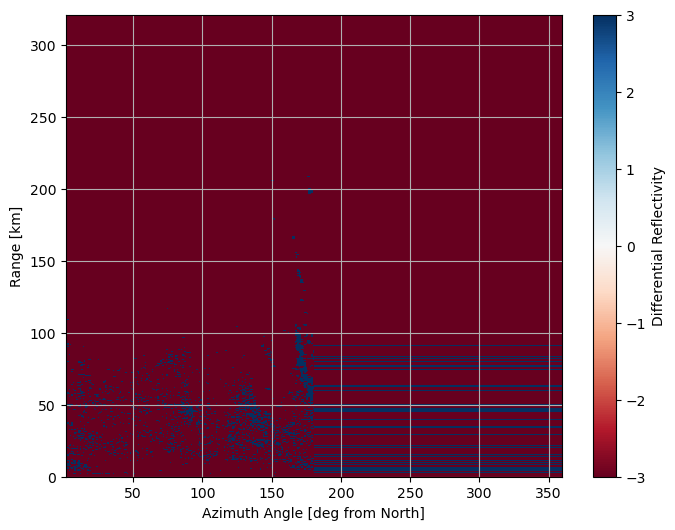

In [47]:
fig, ax = plt.subplots(figsize=(8,6))
RangeViewer = pcolormeshC(Thetas+180, Ranges*0.001, np.transpose(ZDR3D[0]), ax=ax, cmap='RdBu', vmin=-3, vmax=3)

ax.set_xlabel('Azimuth Angle [deg from North]')
ax.set_ylabel('Range [km]')
plt.colorbar(RangeViewer, ax=ax, label = 'Differential Reflectivity')
plt.grid()

plt.show()

Text(0.5, 1.0, 'Scanning Azimuth (from N) Angle for each 4680 times')

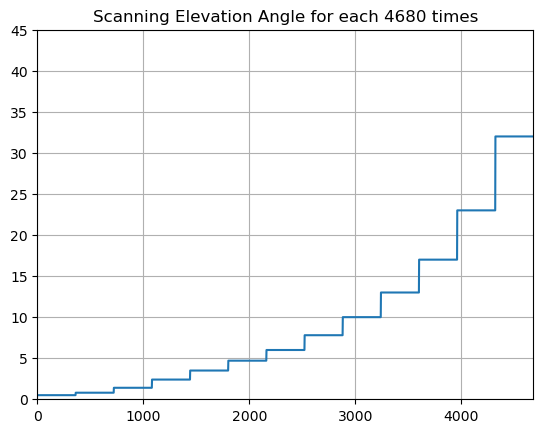

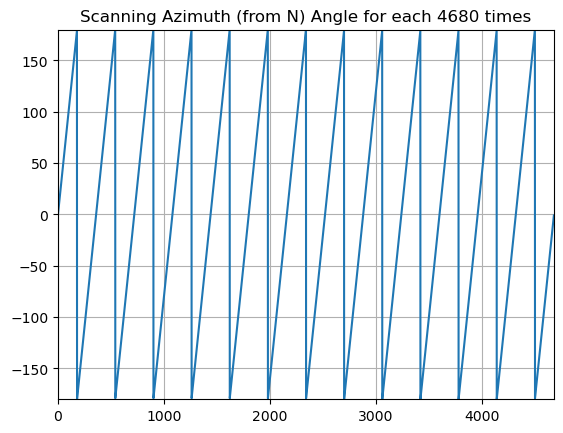

In [62]:
# plot a quick view of the elevation angle over all "4680" times


elev = np.array(RadarDataStruct.elevation)
x = np.arange(0,len(elev),1)

plt.figure()
plt.plot(x, elev)
plt.grid()

plt.xlim([0,len(elev)])
plt.ylim([0,45])
plt.title('Scanning Elevation Angle for each 4680 times')

azi = np.array(RadarDataStruct.azimuth)
x2 = np.arange(0,len(azi),1)

plt.figure()
plt.plot(x2, azi)
plt.grid()

plt.xlim([0,len(azi)])
plt.ylim([-180,180])
plt.title('Scanning Azimuth (from N) Angle for each 4680 times')

In [20]:
# LEVEL 2 DATA VIEWER

# Choose LEVEL 2 variable to view (both ALL CAPS and all lower case are used in the file names)
# (options are         'AZSHEAR', 'COLUMNMAXREFLECTIVITY',   'ECHOTOPHEIGHT', 'REFLECTIVITY',               'SHI', and                     'STEINER')
# (options are (Azimuthal Shear),          (Column Max Z), (Echo Top Height),    (Ground? Z), (Severe Hail Index), and 'Steiner Echo Classification')
VARIABLEupper = 'STEINER'
VARIABLElower = 'steiner'

# path to the radar data netcdf
NCFolder = '/g/data/rq0/level_2/' + RadarIDno + '/' + VARIABLEupper + '/' # + str(RadarYear) + '/'
NCFile   =  RadarIDno + '_' + RadarFileDate + '_' + VARIABLElower + '.nc'

# place where the netcdf file lives
NCPath = NCFolder + NCFile

RadarDataStruct = xr.open_dataset(NCFolder + NCFile, engine='netcdf4')

RadarDataStruct

<xarray.Dataset> Size: 209MB
Dimensions:    (time: 288, y: 301, x: 301)
Coordinates:
  * time       (time) datetime64[ns] 2kB 2024-01-01 ... 2024-01-01T23:55:00
  * y          (y) int32 1kB -150000 -149000 -148000 ... 148000 149000 150000
  * x          (x) int32 1kB -150000 -149000 -148000 ... 148000 149000 150000
Data variables:
    steiner    (time, y, x) float64 209MB ...
    longitude  (y, x) float32 362kB ...
    latitude   (y, x) float32 362kB ...
    isfile     (time) int32 1kB ...
Attributes: (12/57)
    summary:                       Level 2 dataset from the Australian radar ...
    history:                       created by Joshua Soderholm on gadi.nci.or...
    acknowledgement:               This work is support by the Bureau of Mete...
    institution:                   Bureau of Meteorology
    keywords:                      radar, Doppler, dual-polarization
    licence:                       CC4.0-BY-NC (if the latest dataset licence...
    ...                            ...
    geospatial_vertical_min:       2500
    geospatial_vertical_max:       2500
    comments:                      Radar reflectivity has not been corrected ...
    geospatial_projection:         Azimuthal equidistant projection
    geospatial_vertical_positive:  up
    geospatial_vertical_units:     m

In [20]:
# THIS BLOCK IS WHERE THE USER PUTS INFO ABOUT THE RADAR

# the reference number for the radar location (ie 20 is Mackay)
RadarIDno = '22'  # 22 is Mackay, 106 is Townsville, 66 is Mt Staplyton (Brisbane) , 50 is Marabong (near Bris)
GridOrPPI = 'grid'

# the day in consideration (YYYYMMDD) and time (hhmmss)
# ALL IN UTC !!!
RadarYear  = 2026
RadarMonth = 4
RadarDay   = 30

RadarFileDate  = str(RadarYear).zfill(4) + str(RadarMonth).zfill(2) + str(RadarDay).zfill(2)
RadarFileTime =   '120000'

In [21]:
# LEVEL 1 DATA unzipper

# path to the radar data zip files
ZipFolder = '/g/data/rq0/level_1/odim_pvol/' + RadarIDno + '/' + str(RadarYear) + '/vol/'
ZipFile   =  RadarIDno + '_' + RadarFileDate + '.pvol.zip'

# place where the Zip file lives
ZipPath = ZipFolder + ZipFile

# place to extract the files to
ExtractToDirectory = Path('/scratch/v46/sg3241/tmp/UnzippedRadarFiles/Level1/vol/'  + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_pvol/')

# Create the extraction folder (only if you haven't already)
if not Path(ExtractToDirectory).exists():
    ExtractToDirectory.mkdir(parents=True, exist_ok=True)

    # actually do the unzipping
    with zp.ZipFile(ZipPath, 'r') as ZipReference:
        ZipReference.extractall(ExtractToDirectory)

    print('Done')
else:
    print('Unzipped Folder Already Exists')

Done


In [24]:
# LEVEL 1 DATA viewer

# the path of where the UNZIPPED radar data now live
RadarFolder = '/scratch/v46/sg3241/tmp/UnzippedRadarFiles/Level1/vol/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_pvol/'
RadarFile   = RadarIDno + '_' + RadarFileDate + '_' + RadarFileTime + '.pvol.h5'

RadarPath = RadarFolder + RadarFile

# scratch/v46/sg3241/tmp/UnzippedRadarFiles/Level1/vol/22/22_20240101_pvol/22_20240101_000500.pvol.h5

#Open the H5 file in read mode
with h5py.File(RadarPath, 'r') as f:

    def print_structure(name, obj):

        print(name, type(obj))

    f.visititems(print_structure)

dataset1 <class 'h5py._hl.group.Group'>
dataset1/data1 <class 'h5py._hl.group.Group'>
dataset1/data1/data <class 'h5py._hl.dataset.Dataset'>
dataset1/data1/how <class 'h5py._hl.group.Group'>
dataset1/data1/what <class 'h5py._hl.group.Group'>
dataset1/data10 <class 'h5py._hl.group.Group'>
dataset1/data10/data <class 'h5py._hl.dataset.Dataset'>
dataset1/data10/what <class 'h5py._hl.group.Group'>
dataset1/data11 <class 'h5py._hl.group.Group'>
dataset1/data11/data <class 'h5py._hl.dataset.Dataset'>
dataset1/data11/how <class 'h5py._hl.group.Group'>
dataset1/data11/what <class 'h5py._hl.group.Group'>
dataset1/data12 <class 'h5py._hl.group.Group'>
dataset1/data12/data <class 'h5py._hl.dataset.Dataset'>
dataset1/data12/how <class 'h5py._hl.group.Group'>
dataset1/data12/what <class 'h5py._hl.group.Group'>
dataset1/data2 <class 'h5py._hl.group.Group'>
dataset1/data2/data <class 'h5py._hl.dataset.Dataset'>
dataset1/data2/how <class 'h5py._hl.group.Group'>
dataset1/data2/what <class 'h5py._hl.gro

In [31]:
# INSPECT THE VALUES OF THE VARIABLE

with h5py.File(RadarPath, 'r') as f:

    d = f['dataset1/data1/data']

    print("Shape:", d.shape)

    print("Dtype:", d.dtype)

    data = d[:]

    print(data)

Shape: (360, 80)
Dtype: uint8
[[ 0  0 51 ...  0  0  0]
 [ 0 46 57 ...  0  0  0]
 [ 0 43 50 ...  0  0  0]
 ...
 [ 0 41 52 ...  0  0  0]
 [ 0 57 48 ...  0  0  0]
 [ 0 64 49 ... 41 43  0]]


In [32]:
# CHECK WHAT VARIABLE YOU ARE DEALING WITH

with h5py.File(RadarPath, 'r') as f:

    what = f['dataset1/data1/what']

    for k, v in what.attrs.items():

        print(k, v)

gain 0.5
nodata 0.0
offset -32.0
quantity b'DBZH'
undetect 0.0


In [ ]:
# THIS BLOCK TAKES A ZIPPED FOLDER FROM /G/DATA/ AND UNZIPS IT TO A FOLDER "nzippedRadarFiles" IN SCRATCH

# PATH NAMES
# ZippedFolder = '/g/data/rq0/level_1b/22/ppi/2024/'
ZippedFolder = '/g/data/rq0/level_1b/' + RadarIDno + '/' + GridOrPPI + '/' + str(RadarYear) + '/'
ZippedFile   =  RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '.zip'

# place where the zipped file lives
ZippedPath = ZippedFolder + ZippedFile
# place to extract the files to
ExtractToDirectory = Path('/scratch/v46/sg3241/tmp/UnzippedRadarFiles/' + RadarIDno + '/' + RadarIDno + '_' + RadarFileDate + '_' + GridOrPPI + '/')

# Create the extraction folder (only if you haven't already)
if not Path(ExtractToDirectory).exists():
    ExtractToDirectory.mkdir(parents=True, exist_ok=True)

    # actually do the unzipping
    with zp.ZipFile(ZippedPath, 'r') as ZipReference:
        ZipReference.extractall(ExtractToDirectory)

    print('Done')
else:
    print('Unzipped Folder Already Exists')

In [ ]:
# CONVERTS STORED VALUES TO REAL VALUES

with h5py.File(RadarPath, 'r') as f:

    raw = f['dataset7/data1/data'][:]
    attrs = f['dataset7/data1/what'].attrs
    gain = attrs['gain']
    offset = attrs['offset']

    nodata = attrs['nodata']

    data = raw.astype(float)
    data[raw == nodata] = np.nan
    data = offset + gain * data

    print(data)

In [ ]:
with h5netcdf.File("mydata.nc", "w") as f:
    # set dimensions with a dictionary
    f.dimensions = {"x": 5}
    # and update them with a dict-like interface
    # f.dimensions['x'] = 5
    # f.dimensions.update({'x': 5})

    v = f.create_variable("hello", ("x",), float)
    v[:] = np.ones(5)

    # you don't need to create groups first
    # you also don't need to create dimensions first if you supply data
    # with the new variable
    v = f.create_variable("/grouped/data", ("y",), data=np.arange(10))

    # access and modify attributes with a dict-like interface
    v.attrs["foo"] = "bar"

    # you can access variables and groups directly using a hierarchical
    # keys like h5py
    print(f["/grouped/data"])

    # add an unlimited dimension
    f.dimensions["z"] = None
    # explicitly resize a dimension and all variables using it
    f.resize_dimension("z", 3)